In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt



In [25]:
# -----------------------------
# Reproducibility
# -----------------------------
torch.manual_seed(42)

# -----------------------------
# Model parameters
# -----------------------------
d = 2
T = 5.0
N_steps = 100
dt = T / N_steps
sqrt_dt = dt ** 0.5

M = 512          # number of Monte Carlo paths
n_iter = 1500
nature_steps = 1

lr_agent = 1e-3
lr_nature = 5e-4
lambda_K = 1e-3

device = "cpu"

# Stationary covariance Sigma and instantaneous covariance c
Sigma = torch.tensor([[1.0, 0.3],
                      [0.3, 1.5]], dtype=torch.float32, device=device)

c = torch.torch.tensor([[1.5, 0.7],
                      [0.7, 2]], dtype=torch.float32, device=device)

Sigma_inv = torch.inverse(Sigma)
sigma = torch.linalg.cholesky(c)

# Analytical robust strategy and growth rate
def theta_star(x):
    return -0.5 * x @ Sigma_inv.T

g_star = 0.125 * torch.trace(Sigma_inv @ c).item()
print("Analytical robust growth rate:", g_star)




Analytical robust growth rate: 0.3395389914512634


In [26]:
# -----------------------------
# Agent neural network
# -----------------------------
class AgentNN(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, d)
        )

    def forward(self, x):
        return self.net(x)




In [27]:
# -----------------------------
# Nature: trainable skew-symmetric K
# -----------------------------
class NatureK(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.d = d
        self.n_params = d * (d - 1) // 2
        self.xi = nn.Parameter(torch.zeros(self.n_params))

    def K_matrix(self):
        K = torch.zeros((self.d, self.d), dtype=torch.float32, device=self.xi.device)
        idx = 0
        for i in range(self.d):
            for j in range(i + 1, self.d):
                K[i, j] = self.xi[idx]
                K[j, i] = -self.xi[idx]
                idx += 1
        return K

    def B_matrix(self):
        K = self.K_matrix()
        return (0.5 * c + K) @ Sigma_inv




In [28]:
agent = AgentNN(d).to(device)
nature = NatureK(d).to(device)

opt_agent = optim.Adam(agent.parameters(), lr=lr_agent)
opt_nature = optim.Adam(nature.parameters(), lr=lr_nature)




In [29]:
# -----------------------------
# Sampling initial condition
# X_0 ~ N(0, Sigma)
# -----------------------------
def sample_initial(M):
    z = torch.randn(M, d, device=device)
    L = torch.linalg.cholesky(Sigma)
    return z @ L.T


# -----------------------------
# Simulate OU paths and compute empirical growth
# -----------------------------
def empirical_growth(agent, nature, M):
    B = nature.B_matrix()
    X = sample_initial(M)

    log_growth = torch.zeros(M, device=device)

    for _ in range(N_steps):
        theta = agent(X)

        dW = torch.randn(M, d, device=device) * sqrt_dt
        drift = -(X @ B.T) * dt
        diffusion = dW @ sigma.T
        dX = drift + diffusion

        quad = torch.sum((theta @ c) * theta, dim=1)

        dlogV = torch.sum(theta * dX, dim=1) - 0.5 * quad * dt
        log_growth += dlogV

        X = X + dX

    return torch.mean(log_growth) / T




In [30]:
# -----------------------------
# Training loop
# -----------------------------
growth_history = []
K_history = []

for it in range(n_iter):

    # ----- Nature step: minimize growth -----
    for _ in range(nature_steps):
        opt_nature.zero_grad()

        g_hat = empirical_growth(agent, nature, M)
        K = nature.K_matrix()

        loss_nature = g_hat #+ lambda_K * torch.sum(K ** 2)
        loss_nature.backward()

        torch.nn.utils.clip_grad_norm_(nature.parameters(), max_norm=1.0)
        opt_nature.step()

    # ----- Agent step: maximize growth -----
    opt_agent.zero_grad()

    g_hat = empirical_growth(agent, nature, M)
    loss_agent = -g_hat
    loss_agent.backward()

    torch.nn.utils.clip_grad_norm_(agent.parameters(), max_norm=1.0)
    opt_agent.step()

    growth_history.append(g_hat.item())
    K_history.append(torch.norm(nature.K_matrix()).item())

    if it % 100 == 0:
        print(
            f"Iter {it:4d} | "
            f"g_hat = {g_hat.item():.5f} | "
            f"K_norm = {K_history[-1]:.5f}"
        )




Iter    0 | g_hat = -0.08701 | K_norm = 0.00071
Iter  100 | g_hat = 0.34369 | K_norm = 0.00753
Iter  200 | g_hat = 0.33174 | K_norm = 0.00010
Iter  300 | g_hat = 0.32764 | K_norm = 0.00082
Iter  400 | g_hat = 0.33258 | K_norm = 0.00311
Iter  500 | g_hat = 0.34805 | K_norm = 0.00110
Iter  600 | g_hat = 0.34256 | K_norm = 0.00552
Iter  700 | g_hat = 0.33189 | K_norm = 0.00672
Iter  800 | g_hat = 0.34469 | K_norm = 0.00248
Iter  900 | g_hat = 0.33868 | K_norm = 0.00186
Iter 1000 | g_hat = 0.36625 | K_norm = 0.00089
Iter 1100 | g_hat = 0.34476 | K_norm = 0.00213
Iter 1200 | g_hat = 0.35139 | K_norm = 0.00624
Iter 1300 | g_hat = 0.34432 | K_norm = 0.00065
Iter 1400 | g_hat = 0.35820 | K_norm = 0.00126


In [31]:
# -----------------------------
# Final evaluation
# -----------------------------
with torch.no_grad():
    g_learned = empirical_growth(agent, nature, 5000).item()
    K_final = nature.K_matrix()
    B_final = nature.B_matrix()

print("\nFinal learned growth:", g_learned)
print("Analytical robust growth:", g_star)
print("\nFinal K:")
print(K_final)
print("\nFinal B:")
print(B_final)





Final learned growth: 0.35165342688560486
Analytical robust growth: 0.3395389914512634

Final K:
tensor([[ 0.0000, -0.0030],
        [ 0.0030,  0.0000]])

Final B:
tensor([[0.7241, 0.0865],
        [0.1628, 0.6341]])


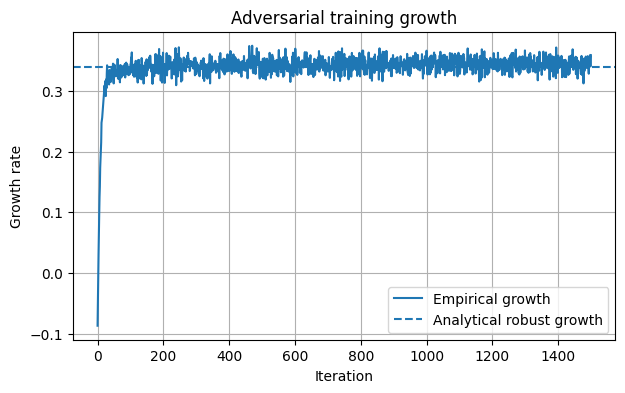

In [32]:
# -----------------------------
# Plot training growth
# -----------------------------
plt.figure(figsize=(7, 4))
plt.plot(growth_history, label="Empirical growth")
plt.axhline(g_star, linestyle="--", label="Analytical robust growth")
plt.xlabel("Iteration")
plt.ylabel("Growth rate")
plt.legend()
plt.title("Adversarial training growth")
plt.grid(True)
plt.show()




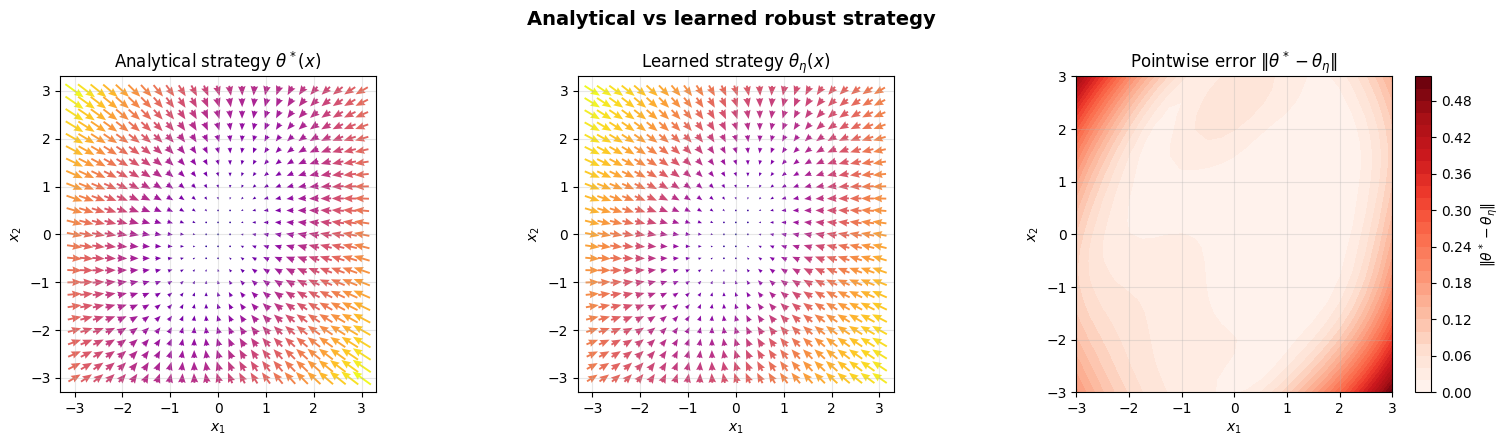

In [33]:
# -----------------------------
# Vector field plots:
# analytical strategy, learned strategy, pointwise error
# -----------------------------

import numpy as np

# Grid in R^2
grid_min, grid_max = -3.0, 3.0
n_grid = 25

x1 = torch.linspace(grid_min, grid_max, n_grid, device=device)
x2 = torch.linspace(grid_min, grid_max, n_grid, device=device)

X1, X2 = torch.meshgrid(x1, x2, indexing="ij")

# Flatten grid points: shape (n_grid*n_grid, 2)
X_grid = torch.stack([X1.reshape(-1), X2.reshape(-1)], dim=1)

with torch.no_grad():
    theta_learned = agent(X_grid)
    theta_true = theta_star(X_grid)

# Convert to numpy arrays for plotting
X1_np = X1.cpu().numpy()
X2_np = X2.cpu().numpy()

theta_true_np = theta_true.cpu().numpy()
theta_learned_np = theta_learned.cpu().numpy()

U_true = theta_true_np[:, 0].reshape(n_grid, n_grid)
V_true = theta_true_np[:, 1].reshape(n_grid, n_grid)

U_learned = theta_learned_np[:, 0].reshape(n_grid, n_grid)
V_learned = theta_learned_np[:, 1].reshape(n_grid, n_grid)

# Pointwise error ||theta_true - theta_learned||
error = torch.norm(theta_true - theta_learned, dim=1)
error_np = error.cpu().numpy().reshape(n_grid, n_grid)

# Magnitudes for color in vector fields
mag_true = np.sqrt(U_true**2 + V_true**2)
mag_learned = np.sqrt(U_learned**2 + V_learned**2)

# -----------------------------
# Plot all three panels together
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Analytical vector field
q0 = axes[0].quiver(
    X1_np, X2_np,
    U_true, V_true,
    mag_true,
    cmap="plasma",
    angles="xy",
    scale_units="xy",
    scale=5,              # smaller scale => larger arrows
    width=0.006,          # thicker arrows
    headwidth=4,
    headlength=5,
    headaxislength=4.5,
    pivot="mid"
)
axes[0].set_title(r"Analytical strategy $\theta^*(x)$")
axes[0].set_xlabel(r"$x_1$")
axes[0].set_ylabel(r"$x_2$")
axes[0].set_aspect("equal")
axes[0].grid(True, alpha=0.3)

# Learned vector field
q1 = axes[1].quiver(
    X1_np, X2_np,
    U_learned, V_learned,
    mag_learned,
    cmap="plasma",
    angles="xy",
    scale_units="xy",
    scale=5,
    width=0.006,
    headwidth=4,
    headlength=5,
    headaxislength=4.5,
    pivot="mid"
)
axes[1].set_title(r"Learned strategy $\theta_{\eta}(x)$")
axes[1].set_xlabel(r"$x_1$")
axes[1].set_ylabel(r"$x_2$")
axes[1].set_aspect("equal")
axes[1].grid(True, alpha=0.3)

# Error heatmap
im = axes[2].contourf(
    X1_np, X2_np,
    error_np,
    levels=30,
    cmap="Reds"
)
axes[2].set_title(r"Pointwise error $\|\theta^*-\theta_\eta\|$")
axes[2].set_xlabel(r"$x_1$")
axes[2].set_ylabel(r"$x_2$")
axes[2].set_aspect("equal")
axes[2].grid(True, alpha=0.3)

cbar = fig.colorbar(im, ax=axes[2])
cbar.set_label(r"$\|\theta^*-\theta_\eta\|$")

fig.suptitle("Analytical vs learned robust strategy", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()